In [1]:
import pandas as pd

path = r"C:\Users\Admin\Desktop\salary prediction\job_salary_prediction_dataset.csv"

df = pd.read_csv(path)

df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [2]:
df.info()
df.isnull().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

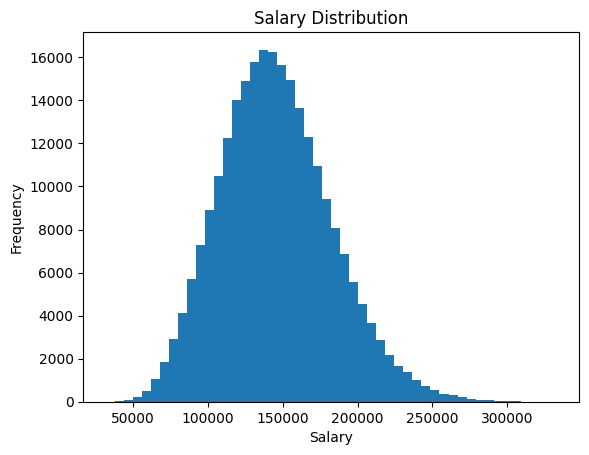

In [5]:
import matplotlib.pyplot as plt

plt.hist(df["salary"], bins=50)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

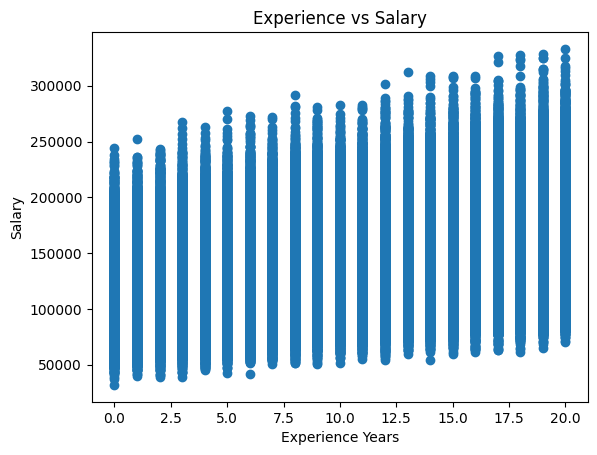

In [6]:
plt.scatter(df["experience_years"], df["salary"])
plt.title("Experience vs Salary")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.show()

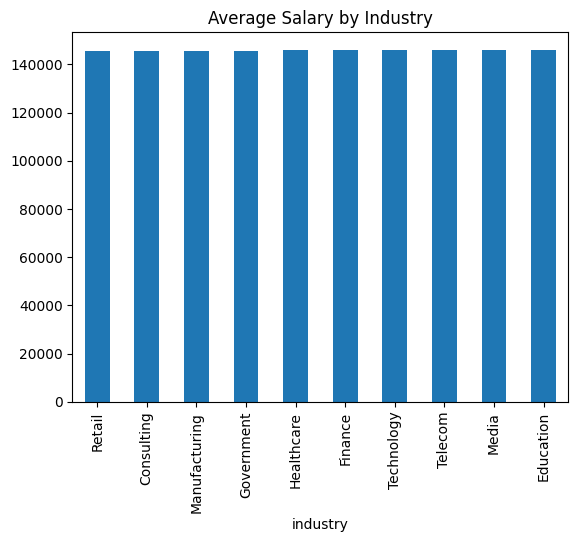

In [7]:
df.groupby("industry")["salary"].mean().sort_values().plot(kind="bar")
plt.title("Average Salary by Industry")
plt.show()

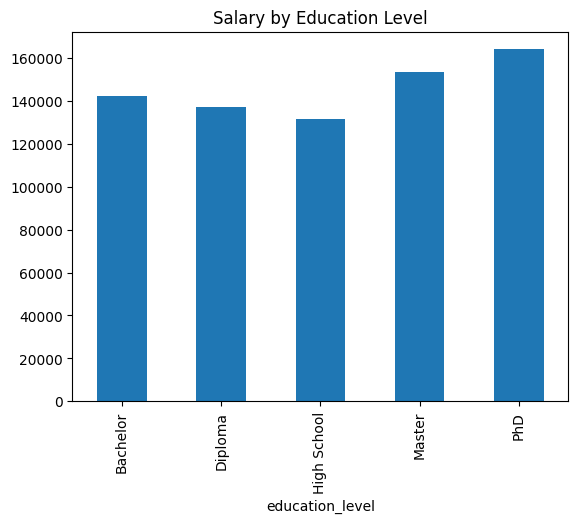

In [8]:
df.groupby("education_level")["salary"].mean().plot(kind="bar")
plt.title("Salary by Education Level")
plt.show()

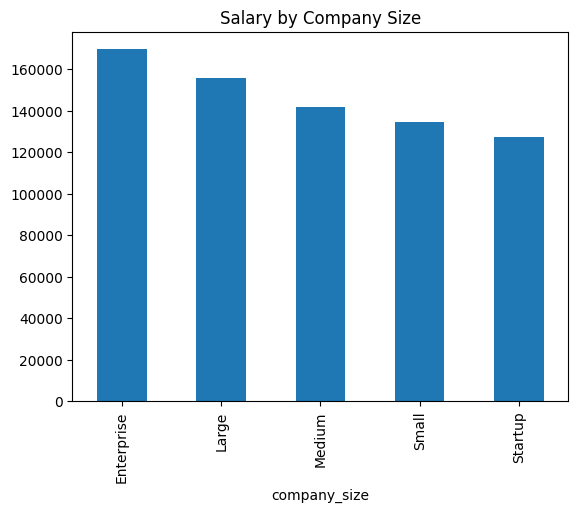

In [9]:
df.groupby("company_size")["salary"].mean().plot(kind="bar")
plt.title("Salary by Company Size")
plt.show()

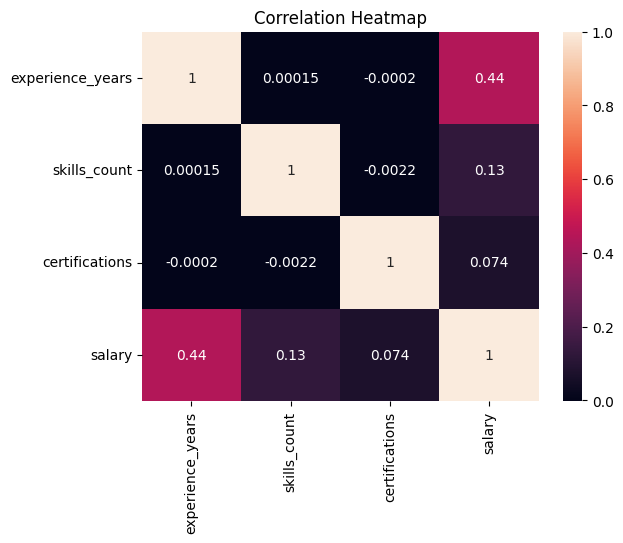

In [10]:
import seaborn as sns

numeric_df = df.select_dtypes(include=["int64"])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
df.describe()

df.groupby("education_level")["salary"].mean().sort_values()

df.groupby("industry")["salary"].mean().sort_values()

df.groupby("company_size")["salary"].mean()

company_size
Enterprise    169616.398957
Large         155711.112489
Medium        141537.535991
Small         134356.864298
Startup       127289.011974
Name: salary, dtype: float64

In [12]:
df_model = df[[
    "experience_years",
    "skills_count",
    "certifications",
    "education_level",
    "industry",
    "company_size",
    "remote_work",
    "salary"
]]

In [13]:
df_model = pd.get_dummies(
    df_model,
    columns=["education_level", "industry", "company_size", "remote_work"],
    drop_first=True
)

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 22825.127373929878
R2 Score: 0.3846437387301411


In [16]:
df["job_title_freq"] = df["job_title"].map(df["job_title"].value_counts())

In [17]:
df_model = df[[
    "experience_years",
    "skills_count",
    "certifications",
    "job_title_freq",   # NEW
    "education_level",
    "industry",
    "company_size",
    "remote_work",
    "salary"
]]

In [18]:
df_model = pd.get_dummies(
    df_model,
    columns=["education_level", "industry", "company_size", "remote_work"],
    drop_first=True
)

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 16358.405940047205
R2 Score: 0.6386275275616184


In [27]:
import numpy as np
y = np.log1p(df_model["salary"])

In [28]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [29]:
from sklearn.metrics import mean_absolute_error, r2_score

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 16330.6728515625
R2 Score: 0.6405774354934692


In [30]:
import joblib

joblib.dump(model, "salary_model.pkl")
joblib.dump(X.columns, "salary_columns.pkl")

['salary_columns.pkl']